# One sample

In [2]:
import numpy as np

def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))
def predict(x, w, b):
    z = w * x + b
    y_hat = sigmoid_function(z)
    return y_hat
def loss_function(x, y_hat, y):
    return -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)
def compute_gradient(x, y_hat, y):
    dw = x * (y_hat - y)
    db = y_hat - y

    return dw, db
def update(w, b, dw, db, learning_rate):
    w = w - learning_rate * dw
    b = b - learning_rate * db

    return w, b

# Vectorization

In [ ]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))
def predict(theta, x):
    z = x.dot(theta)
    y_hat = sigmoid_function(z)
    return y_hat
def compute_loss(y_hat, y):
    #return -np.mean(y * np.log(y_hat) + (1-y) * np.log(1 - y_hat))
    m = y.shape[0]
    return (1/m)*(-y.T.dot(np.log(y_hat)) - (1 - y).T.dot(np.log(1-y_hat)))
def compute_gradient(x, y_hat, y):
    m = x.shape[0]
    error = y_hat - y
    # x.T có kích thước (n, m), (y_hat - y) có kích thước (m, 1)
    # Kết quả dtheta sẽ là (n, 1) - khớp hoàn toàn với chiều của theta
    dtheta = (1/m) * x.T.dot(error)
    return dtheta
def update(theta, dtheta, learning_rate): 
    theta = theta - learning_rate * dtheta
    return theta

In [21]:
X_data = np.array([
    [1.4, 0.2],
    [1.5, 0.2],
    [3, 1.1],
    [4.1, 1.3]
])
y_data = np.array([0, 0, 1, 1])

X_data_b = np.c_[np.ones((len(X_data))), X_data]
X_data_b

array([[1. , 1.4, 0.2],
       [1. , 1.5, 0.2],
       [1. , 3. , 1.1],
       [1. , 4.1, 1.3]])

In [8]:
theta = np.random.rand(X_data_b.shape[1])
theta

array([0.53201673, 0.00109493, 0.91786037])

In [29]:
learning_rate = 0.01
epochs = 100
losses = []
for num_epoch in range(epochs):
    # Predict
    y_hat = predict(theta=theta, x=X_data_b)

    # Compute loss
    loss = compute_loss(y_hat=y_hat, y=y_data)
    losses.append(loss)

    if num_epoch % 10 == 0:
        print(f'Epoch {num_epoch}: {loss}')
    
    # Compute gradient
    dtheta = compute_gradient(x=X_data_b, y_hat=y_hat, y=y_data)

    # Update
    theta = theta - learning_rate * dtheta
print(theta)

Epoch 0: 0.023503874167326383
Epoch 10: 0.023494705473186467
Epoch 20: 0.023485543928443355
Epoch 30: 0.023476389524750393
Epoch 40: 0.02346724225377414
Epoch 50: 0.023458102107193807
Epoch 60: 0.023448969076701784
Epoch 70: 0.02343984315400302
Epoch 80: 0.02343072433081557
Epoch 90: 0.02342161259887038
[-6.46043595  1.31368501  5.4910183 ]


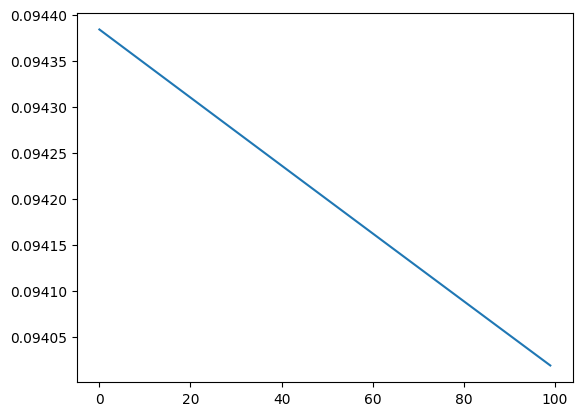

In [27]:
import matplotlib.pyplot as plt

plt.plot(losses)